# Program 12: HBMO Implementations

This notebook implements:
1) HBMO-based gradient descent learning for a FLANN classifier and comparison against GA-based FLANN and PSO-based FLANN.
2) HBMO for the Euclidean Traveling Salesman Problem (TSP).

## Part A: FLANN + GA / PSO / HBMO

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)

In [2]:
# Data preparation
iris = load_iris()
X_raw = iris.data
y = iris.target
num_classes = len(np.unique(y))

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_raw = scaler.fit_transform(X_train_raw)
X_test_raw = scaler.transform(X_test_raw)

def flann_expand(X):
    """Functional-link expansion: [x, sin(pi x), cos(pi x), x^2]."""
    return np.hstack([X, np.sin(np.pi * X), np.cos(np.pi * X), X ** 2])

X_train = flann_expand(X_train_raw)
X_test = flann_expand(X_test_raw)

input_dim = X_train.shape[1]
print('Expanded input dim:', input_dim)

Expanded input dim: 16


In [3]:
# FLANN model helpers (single layer + softmax)
def one_hot(y, c):
    y_oh = np.zeros((len(y), c))
    y_oh[np.arange(len(y)), y] = 1.0
    return y_oh

Y_train = one_hot(y_train, num_classes)

def unpack_params(theta, d, c):
    w_size = d * c
    W = theta[:w_size].reshape(d, c)
    b = theta[w_size:w_size + c]
    return W, b

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    expz = np.exp(z)
    return expz / (np.sum(expz, axis=1, keepdims=True) + 1e-12)

def flann_logits(theta, X, d, c):
    W, b = unpack_params(theta, d, c)
    return X @ W + b

def flann_loss(theta, X, Y, d, c, reg=1e-4):
    logits = flann_logits(theta, X, d, c)
    probs = softmax(logits)
    ce = -np.mean(np.sum(Y * np.log(probs + 1e-12), axis=1))
    W, _ = unpack_params(theta, d, c)
    return ce + reg * np.sum(W * W)

def flann_grad(theta, X, Y, d, c, reg=1e-4):
    n = X.shape[0]
    W, b = unpack_params(theta, d, c)
    logits = X @ W + b
    probs = softmax(logits)
    diff = (probs - Y) / n

    dW = X.T @ diff + 2 * reg * W
    db = np.sum(diff, axis=0)

    return np.concatenate([dW.ravel(), db])

def flann_predict(theta, X, d, c):
    logits = flann_logits(theta, X, d, c)
    return np.argmax(logits, axis=1)

def flann_accuracy(theta, X, y, d, c):
    preds = flann_predict(theta, X, d, c)
    return accuracy_score(y, preds)

param_dim = input_dim * num_classes + num_classes
print('Parameter dim:', param_dim)

Parameter dim: 51


In [4]:
# Shared initialization
def random_theta(scale=0.3):
    return np.random.uniform(-scale, scale, size=param_dim)

def gradient_descent(theta0, X, Y, d, c, lr=0.05, steps=60):
    theta = theta0.copy()
    for _ in range(steps):
        theta -= lr * flann_grad(theta, X, Y, d, c)
    return theta

In [5]:
# GA-based FLANN
def run_ga_flann(X, Y, d, c, pop_size=30, generations=60, cx_rate=0.8, mut_rate=0.05):
    pop = [random_theta() for _ in range(pop_size)]

    for _ in range(generations):
        losses = np.array([flann_loss(ind, X, Y, d, c) for ind in pop])
        fitness = 1.0 / (losses + 1e-12)

        elite_idx = np.argmin(losses)
        elite = pop[elite_idx].copy()

        probs = fitness / np.sum(fitness)
        cdf = np.cumsum(probs)

        def select_one():
            r = np.random.rand()
            return pop[np.searchsorted(cdf, r)].copy()

        new_pop = []
        while len(new_pop) < pop_size - 1:
            p1, p2 = select_one(), select_one()
            c1, c2 = p1.copy(), p2.copy()
            if np.random.rand() < cx_rate:
                mask = np.random.rand(param_dim) > 0.5
                c1[mask], c2[mask] = p2[mask], p1[mask]

            for child in (c1, c2):
                m = np.random.rand(param_dim) < mut_rate
                child[m] += np.random.normal(0, 0.1, size=np.sum(m))
                new_pop.append(child)
                if len(new_pop) >= pop_size - 1:
                    break

        new_pop.append(elite)
        pop = new_pop[:pop_size]

    final_losses = np.array([flann_loss(ind, X, Y, d, c) for ind in pop])
    return pop[np.argmin(final_losses)].copy()

In [6]:
# PSO-based FLANN
def run_pso_flann(X, Y, d, c, swarm_size=30, iterations=80, w=0.72, c1=1.49, c2=1.49):
    particles = np.array([random_theta() for _ in range(swarm_size)])
    velocities = np.zeros_like(particles)

    pbest = particles.copy()
    pbest_loss = np.array([flann_loss(p, X, Y, d, c) for p in particles])

    g_idx = np.argmin(pbest_loss)
    gbest = pbest[g_idx].copy()
    gbest_loss = pbest_loss[g_idx]

    for _ in range(iterations):
        r1 = np.random.rand(swarm_size, param_dim)
        r2 = np.random.rand(swarm_size, param_dim)

        velocities = (
            w * velocities
            + c1 * r1 * (pbest - particles)
            + c2 * r2 * (gbest - particles)
        )
        particles = particles + velocities

        losses = np.array([flann_loss(p, X, Y, d, c) for p in particles])
        improved = losses < pbest_loss
        pbest[improved] = particles[improved]
        pbest_loss[improved] = losses[improved]

        current_best_idx = np.argmin(pbest_loss)
        if pbest_loss[current_best_idx] < gbest_loss:
            gbest_loss = pbest_loss[current_best_idx]
            gbest = pbest[current_best_idx].copy()

    return gbest

In [7]:
# HBMO-based gradient descent learning for FLANN
def hbmo_mate_prob(speed, fitness, queen_fitness):
    delta = abs(fitness - queen_fitness)
    return np.exp(-delta / (speed + 1e-12))

def run_hbmo_gd_flann(
    X, Y, d, c,
    colony_size=30,
    generations=40,
    spermatheca_size=10,
    speed0=1.0,
    alpha=0.92,
    gd_steps_worker=20,
    worker_lr=0.05
):
    # Initialize queen and drones
    queen = random_theta()
    drones = [random_theta() for _ in range(colony_size)]

    queen_f = flann_loss(queen, X, Y, d, c)

    for _ in range(generations):
        drone_losses = np.array([flann_loss(dr, X, Y, d, c) for dr in drones])
        order = np.argsort(drone_losses)

        # Mating flight
        speed = speed0
        spermatheca = []
        for idx in order:
            if len(spermatheca) >= spermatheca_size:
                break

            dr = drones[idx]
            dr_f = drone_losses[idx]
            if np.random.rand() < hbmo_mate_prob(speed, dr_f, queen_f):
                spermatheca.append(dr.copy())
            speed *= alpha

        # If no mating, keep best drone as fallback
        if len(spermatheca) == 0:
            spermatheca.append(drones[order[0]].copy())

        # Generate broods + worker (GD) improvement
        broods = []
        for dr in spermatheca:
            # Arithmetic recombination in continuous space
            beta = np.random.rand(param_dim)
            brood = beta * queen + (1 - beta) * dr

            # Mutation
            m = np.random.rand(param_dim) < 0.05
            brood[m] += np.random.normal(0, 0.08, size=np.sum(m))

            # Worker bees: local gradient descent refinement
            brood = gradient_descent(brood, X, Y, d, c, lr=worker_lr, steps=gd_steps_worker)
            broods.append(brood)

        brood_losses = np.array([flann_loss(br, X, Y, d, c) for br in broods])
        best_brood_idx = np.argmin(brood_losses)

        if brood_losses[best_brood_idx] < queen_f:
            queen = broods[best_brood_idx].copy()
            queen_f = brood_losses[best_brood_idx]

        # New drones around queen and random individuals for diversity
        drones = []
        for _ in range(colony_size):
            if np.random.rand() < 0.5:
                dtheta = queen + np.random.normal(0, 0.15, size=param_dim)
            else:
                dtheta = random_theta()
            drones.append(dtheta)

    return queen

In [8]:
# Run comparison: GA-FLANN vs PSO-FLANN vs HBMO+GD-FLANN
ga_theta = run_ga_flann(X_train, Y_train, input_dim, num_classes)
pso_theta = run_pso_flann(X_train, Y_train, input_dim, num_classes)
hbmo_theta = run_hbmo_gd_flann(X_train, Y_train, input_dim, num_classes)

results_flann = {
    'GA-FLANN': {
        'train_loss': float(flann_loss(ga_theta, X_train, Y_train, input_dim, num_classes)),
        'test_acc': float(flann_accuracy(ga_theta, X_test, y_test, input_dim, num_classes))
    },
    'PSO-FLANN': {
        'train_loss': float(flann_loss(pso_theta, X_train, Y_train, input_dim, num_classes)),
        'test_acc': float(flann_accuracy(pso_theta, X_test, y_test, input_dim, num_classes))
    },
    'HBMO+GD-FLANN': {
        'train_loss': float(flann_loss(hbmo_theta, X_train, Y_train, input_dim, num_classes)),
        'test_acc': float(flann_accuracy(hbmo_theta, X_test, y_test, input_dim, num_classes))
    }
}

print('FLANN Comparison Results')
print('-' * 50)
for k, v in results_flann.items():
    print(f"{k:16s} | Train Loss: {v['train_loss']:.4f} | Test Acc: {v['test_acc']:.4f}")

FLANN Comparison Results
--------------------------------------------------
GA-FLANN         | Train Loss: 0.2349 | Test Acc: 0.9556
PSO-FLANN        | Train Loss: 0.0204 | Test Acc: 0.9111
HBMO+GD-FLANN    | Train Loss: 0.0253 | Test Acc: 0.9111


## Part B: HBMO for Euclidean TSP

In [9]:
# Euclidean TSP instance
np.random.seed(7)
num_cities = 30
cities = np.random.rand(num_cities, 2) * 100

def route_length(route, pts):
    total = 0.0
    for i in range(len(route)):
        a = pts[route[i]]
        b = pts[route[(i + 1) % len(route)]]
        total += np.linalg.norm(a - b)
    return total

def random_route(n):
    return np.random.permutation(n)

def ordered_crossover(p1, p2):
    n = len(p1)
    i, j = sorted(np.random.choice(n, 2, replace=False))
    child = -np.ones(n, dtype=int)
    child[i:j+1] = p1[i:j+1]

    fill = [x for x in p2 if x not in child]
    ptr = 0
    for k in range(n):
        if child[k] == -1:
            child[k] = fill[ptr]
            ptr += 1
    return child

def mutate_swap(route, rate=0.2):
    r = route.copy()
    if np.random.rand() < rate:
        i, j = np.random.choice(len(r), 2, replace=False)
        r[i], r[j] = r[j], r[i]
    return r

def two_opt_local(route, pts, steps=30):
    best = route.copy()
    best_len = route_length(best, pts)
    n = len(best)

    for _ in range(steps):
        i, j = sorted(np.random.choice(n, 2, replace=False))
        if i == 0 and j == n - 1:
            continue
        cand = best.copy()
        cand[i:j+1] = cand[i:j+1][::-1]
        cand_len = route_length(cand, pts)
        if cand_len < best_len:
            best, best_len = cand, cand_len
    return best

In [10]:
# HBMO for permutation optimization (TSP)
def hbmo_tsp(pts, colony_size=40, generations=120, spermatheca_size=12, speed0=5.0, alpha=0.93):
    n = len(pts)

    queen = random_route(n)
    queen_len = route_length(queen, pts)
    drones = [random_route(n) for _ in range(colony_size)]

    history = [queen_len]

    for _ in range(generations):
        drone_lens = np.array([route_length(dr, pts) for dr in drones])
        order = np.argsort(drone_lens)

        # Mating flight
        speed = speed0
        spermatheca = []
        for idx in order:
            if len(spermatheca) >= spermatheca_size:
                break
            dr = drones[idx]
            dr_len = drone_lens[idx]
            p = np.exp(-abs(dr_len - queen_len) / (speed + 1e-12))
            if np.random.rand() < p:
                spermatheca.append(dr.copy())
            speed *= alpha

        if len(spermatheca) == 0:
            spermatheca.append(drones[order[0]].copy())

        # Brood generation + worker local search
        broods = []
        for dr in spermatheca:
            brood = ordered_crossover(queen, dr)
            brood = mutate_swap(brood, rate=0.35)
            brood = two_opt_local(brood, pts, steps=35)
            broods.append(brood)

        brood_lens = np.array([route_length(br, pts) for br in broods])
        b_idx = np.argmin(brood_lens)

        if brood_lens[b_idx] < queen_len:
            queen = broods[b_idx].copy()
            queen_len = brood_lens[b_idx]

        history.append(queen_len)

        # Update drones with diversity around queen
        drones = []
        for _ in range(colony_size):
            if np.random.rand() < 0.5:
                dr = mutate_swap(queen, rate=0.8)
            else:
                dr = random_route(n)
            drones.append(dr)

    return queen, queen_len, history

In [11]:
best_route, best_distance, tsp_history = hbmo_tsp(cities)
print('HBMO-TSP Best Distance:', round(best_distance, 4))
print('First 10 cities in best route:', best_route[:10])
print('Initial distance:', round(tsp_history[0], 4))
print('Final distance  :', round(tsp_history[-1], 4))

HBMO-TSP Best Distance: 432.6631
First 10 cities in best route: [10 23 17  7  0 28 24 11 15  8]
Initial distance: 1156.6822
Final distance  : 432.6631


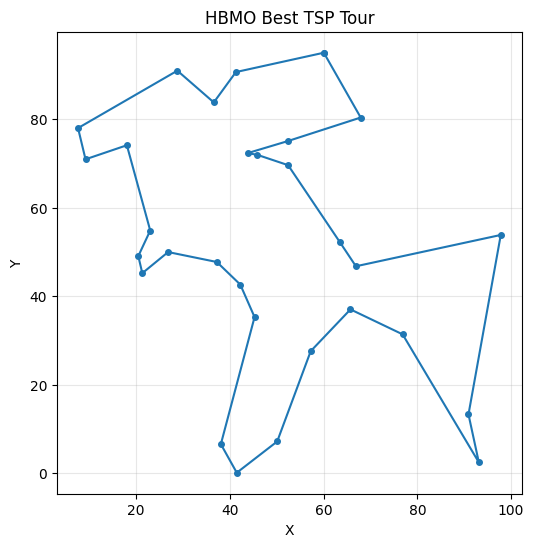

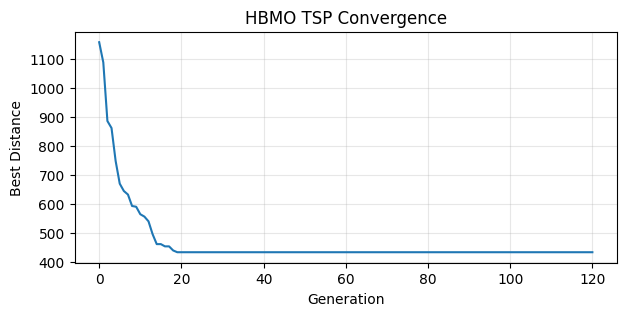

In [12]:
# Optional plot (if matplotlib is available)
try:
    import matplotlib.pyplot as plt

    route_pts = cities[best_route]
    closed = np.vstack([route_pts, route_pts[0]])

    plt.figure(figsize=(6, 6))
    plt.plot(closed[:, 0], closed[:, 1], '-o', markersize=4)
    plt.title('HBMO Best TSP Tour')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.plot(tsp_history)
    plt.title('HBMO TSP Convergence')
    plt.xlabel('Generation')
    plt.ylabel('Best Distance')
    plt.grid(True, alpha=0.3)
    plt.show()
except Exception as e:
    print('Plot skipped:', e)